In [18]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

In [19]:
# processed filepaths

train_bkg = h5py.File('/global/cfs/cdirs/m3246/mbenyas/OmniLearned_distillation/LHCO/nsig_500/lhco_ad/train/bkg.h5')
train_data = h5py.File('/global/cfs/cdirs/m3246/mbenyas/OmniLearned_distillation/LHCO/nsig_500/lhco_ad/train/data.h5')

In [ ]:
def plot_features(h5file):

    # Particle Level Features

    # flattens all delta_eta values into single 1D array, for all N events, and all 2P particles/event
    delta_eta_values = h5file['data'][:, :, 0].ravel()
    delta_phi_values = h5file['data'][:, :, 1].ravel()
    log_pt_values = h5file['data'][:, :, 2].ravel()
    log_e_values = h5file['data'][:, :, 3].ravel()

    delta_eta_values_nonzero = delta_eta_values[log_pt_values != 0.0]
    delta_phi_values_nonzero = delta_phi_values[log_pt_values != 0.0]
    log_pt_values_nonzero = log_pt_values[log_pt_values != 0.0]
    log_e_values_nonzero = log_e_values[log_pt_values != 0.0]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    plots = [
        (delta_eta_values_nonzero, r'$\Delta\eta$'),
        (delta_phi_values_nonzero, r'$\Delta\phi$'),
        (log_pt_values_nonzero, r'$\log(p_T)$'),
        (log_e_values_nonzero, r'$\log(E)$'),
    ]

    for ax, (values, xlabel) in zip(axes.flat, plots):
        ax.hist(values, bins=100, histtype='step', linewidth=1.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()



    # Jet Level Features

    mjj_values = h5file['global'][:, 0]
    jet0_log_pt_values = h5file['global'][:, 1]
    jet0_pt_values = np.array([np.exp(elem) for elem in jet0_log_pt_values])
    jet0_eta_values = h5file['global'][:, 2]
    jet0_phi_values = h5file['global'][:, 3]
    jet0_log_mass_values = h5file['global'][:, 4]
    jet0_multiplicity_values = np.array([elem * 100 for elem in list(h5file['global'][:, 5])])
    jet1_log_pt_values = h5file['global'][:, 6]
    jet1_pt_values = np.array([np.exp(elem) for elem in jet1_log_pt_values])
    jet1_eta_values = h5file['global'][:, 7]
    jet1_phi_values = h5file['global'][:, 8]
    jet1_log_mass_values = h5file['global'][:, 9]
    jet1_multiplicity_values = np.array([elem * 100 for elem in list(h5file['global'][:, 10])])

    plt.figure()
    plt.hist(mjj_values, bins=100, histtype='step', linewidth=1.5)
    plt.xlabel('mjj')
    plt.ylabel('Count')
    plt.show()

    fig, axes = plt.subplots(2, 5, figsize=(16, 6))

    plots = [
        (jet0_pt_values, r'Jet 0 $p_T$'),
        (jet0_eta_values, r'Jet 0 $\eta$'),
        (jet0_phi_values, r'Jet 0 $\phi$'),
        (jet0_log_mass_values, r'Jet 0 $\log(m)$'),
        (jet0_multiplicity_values, r'Jet 0 Multiplicity'),
        (jet1_pt_values, r'Jet 1 $p_T$'),
        (jet1_eta_values, r'Jet 1 $\eta$'),
        (jet1_phi_values, r'Jet 1 $\phi$'),
        (jet1_log_mass_values, r'Jet 1 $\log(m)$'),
        (jet1_multiplicity_values, r'Jet 1 Multiplicity'),
    ]

    for ax, (values, xlabel) in zip(axes.flat, plots):
        ax.hist(values, bins=25, histtype='step', linewidth=1.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()




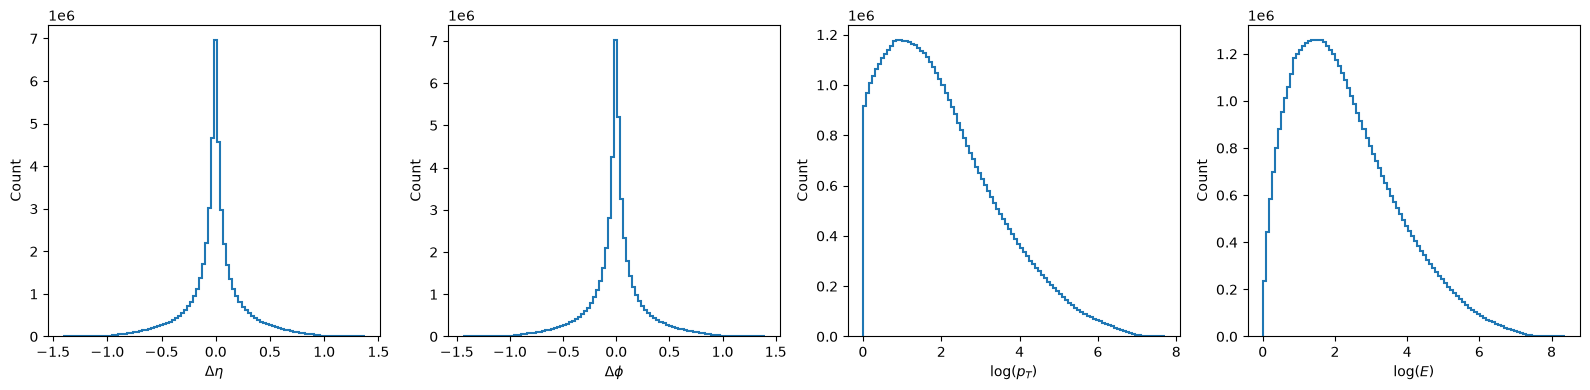

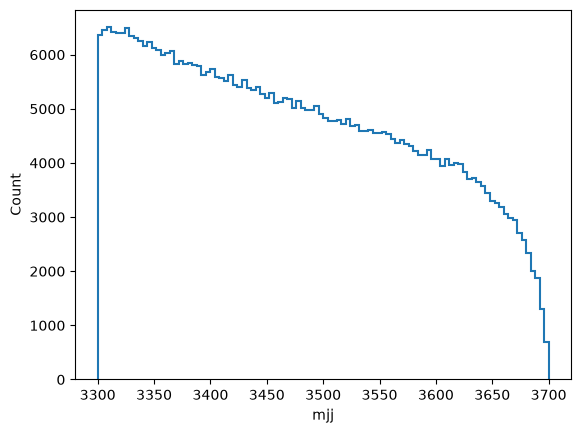

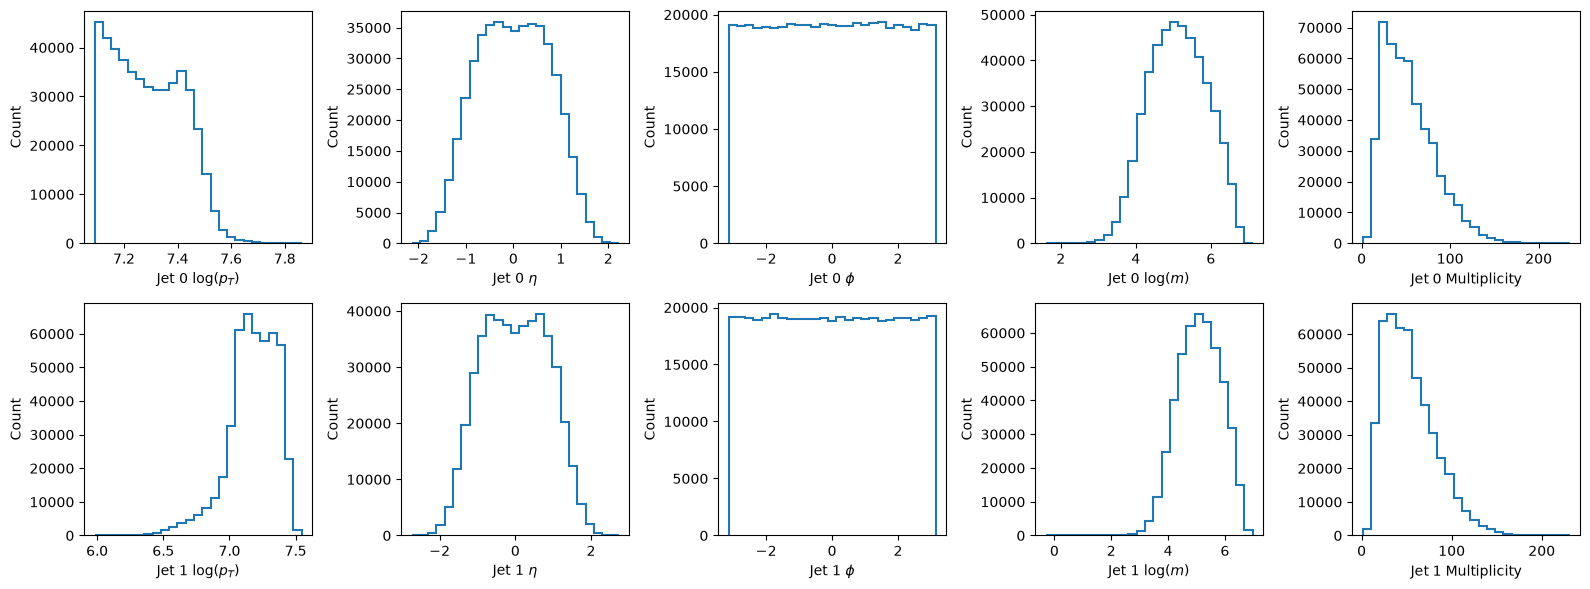

In [27]:
plot_features(train_bkg)

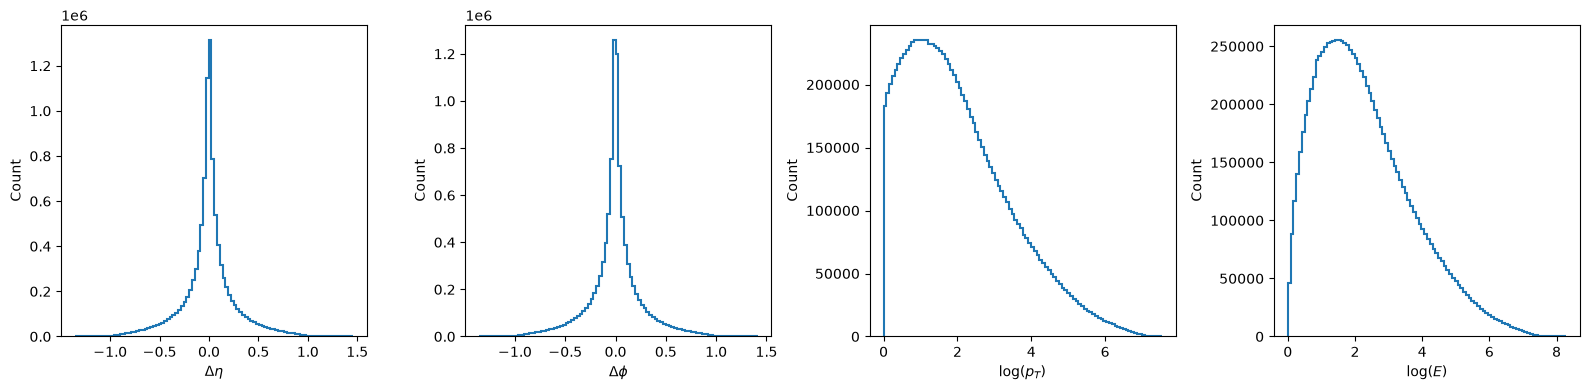

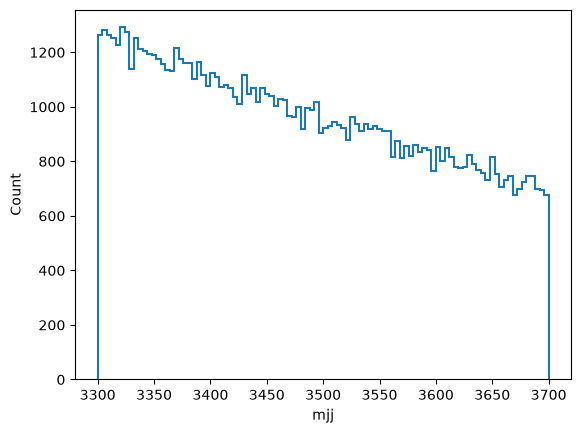

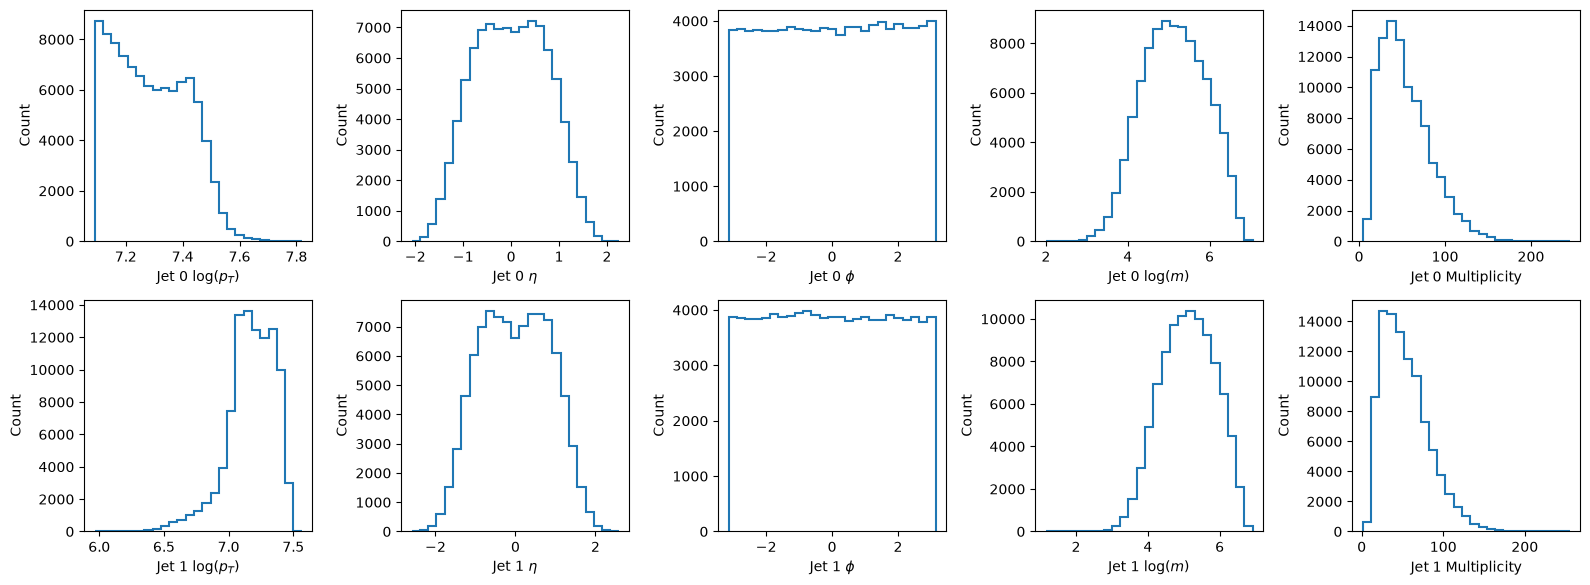

In [28]:
plot_features(train_data)

In [ ]:
train_bkg_extended_Vini = h5py.File('/global/cfs/cdirs/m3246/mbenyas/OmniLearn/LHCO/train_background_SR_extended.h5')

In [ ]:
# compare to Vini's original processed files

orig_jet0_pt_values = train_bkg_extended_Vini['jet'][:, 0, 0]
processed_jet0_pt_values = np.array([np.exp(elem) for elem in train_bkg['global'][:, 1]])
orig_jet1_pt_values = train_bkg_extended_Vini['jet'][:, 1, 0]
processed_jet1_pt_values = np.array([np.exp(elem) for elem in train_bkg['global'][:, 6]])

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

plots = [
    (orig_jet0_pt_values, r'Jet 0 $p_T$ from train_background_SR_extended'),
    (processed_jet0_pt_values, r' Processed Jet 0 $p_T$'),
    (orig_jet1_pt_values, r'Jet 1 $p_T$ from train_background_SR_extended'),
    (processed_jet1_pt_values, r' Processed Jet 1 $p_T$'),
]

for ax, (values, xlabel) in zip(axes.flat, plots):
    ax.hist(values, bins=25, histtype='step', linewidth=1.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()